# 24h Energy Market Analysis

Este notebook reemplaza la lógica del análisis viejo para el entorno con **roles dinámicos por hora**.

## Qué corrige
- Ya no asume vendedores/compradores fijos.
- Soporta columnas de evaluación donde `P` y `M` vienen como **matrices NxN**, no vectores planos.
- Usa `role_vec`, `q`, `p`, `cap` y los `*_state_*` del evaluador.
- Resume resultados **por step** y **por hora**.

## Advertencia importante
Tu notebook anterior estaba mal acoplado al entorno viejo:
- infería `n_sellers` y `n_buyers` a partir de columnas tipo `A0_*` y `A1_*`;
- asumía que `P` era una matriz seller→buyer fija.

Eso ya no aplica para `energy24h_env.py`. En el entorno 24h los IDs son fijos, pero los roles cambian por hora.


In [2]:

import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


In [3]:

def _parse_nested_cell(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (list, tuple)):
        return list(x)
    if not isinstance(x, str):
        return None
    s = x.strip()
    if not s:
        return None
    try:
        v = ast.literal_eval(s)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, (list, tuple)):
            return list(v)
        return v
    except Exception:
        return None


def _infer_vector_len(series):
    vals = series.dropna()
    for v in vals:
        parsed = _parse_nested_cell(v)
        if isinstance(parsed, list):
            return len(parsed)
    return 0


def _infer_matrix_shape(series):
    vals = series.dropna()
    for v in vals:
        parsed = _parse_nested_cell(v)
        if isinstance(parsed, list) and len(parsed) > 0 and isinstance(parsed[0], list):
            rows = len(parsed)
            cols = max(len(r) if isinstance(r, list) else 0 for r in parsed)
            return rows, cols
    return 0, 0


def expand_vector_column(df, col, prefix=None, size=None):
    if col not in df.columns:
        return df, 0
    prefix = prefix or col
    parsed = df[col].apply(_parse_nested_cell)
    size = size or _infer_vector_len(parsed)
    if size <= 0:
        return df, 0

    for i in range(size):
        df[f"{prefix}_{i}"] = parsed.apply(
            lambda v: float(v[i]) if isinstance(v, list) and len(v) > i and not isinstance(v[i], list) else np.nan
        )
    return df, size


def expand_matrix_column(df, col, prefix=None, shape=None):
    if col not in df.columns:
        return df, (0, 0)
    prefix = prefix or col
    parsed = df[col].apply(_parse_nested_cell)
    rows, cols = shape or _infer_matrix_shape(parsed)
    if rows <= 0 or cols <= 0:
        return df, (0, 0)

    for r in range(rows):
        for c in range(cols):
            df[f"{prefix}_{r}_{c}"] = parsed.apply(
                lambda v: float(v[r][c])
                if isinstance(v, list) and len(v) > r and isinstance(v[r], list) and len(v[r]) > c
                else np.nan
            )
    return df, (rows, cols)


def expand_agent_state_columns(df, prefix_agent="agent"):
    state_cols = [c for c in df.columns if c.endswith("_state_0")]
    agent_ids = sorted({c[:-8] for c in state_cols})  # strip _state_0
    if not agent_ids:
        return df, []

    for aid in agent_ids:
        for k, name in enumerate(["q_state", "p_state", "realized_state", "avg_price_state", "role_state"]):
            src = f"{aid}_state_{k}"
            if src in df.columns:
                df[f"{aid}_{name}"] = pd.to_numeric(df[src], errors="coerce")
    return df, agent_ids


In [4]:

def load_eval_dataframe(eval_path):
    df = pd.read_csv(eval_path)
    if "episode" not in df.columns or "step" not in df.columns:
        raise ValueError("evaluation CSV must contain at least 'episode' and 'step' columns")

    df = df.copy()
    df, agent_ids = expand_agent_state_columns(df)

    n_agents = 0
    if "role_vec" in df.columns:
        df, n_agents = expand_vector_column(df, "role_vec", "role")
    elif agent_ids:
        n_agents = len(agent_ids)

    if "q" in df.columns:
        df, qn = expand_vector_column(df, "q", "q")
        n_agents = max(n_agents, qn)
    if "p" in df.columns:
        df, pn = expand_vector_column(df, "p", "p")
        n_agents = max(n_agents, pn)
    if "cap" in df.columns:
        df, cn = expand_vector_column(df, "cap", "cap")
        n_agents = max(n_agents, cn)

    if "P" in df.columns:
        df, shapeP = expand_matrix_column(df, "P", "P")
        n_agents = max(n_agents, shapeP[0], shapeP[1])
    if "M" in df.columns:
        df, shapeM = expand_matrix_column(df, "M", "M")
        n_agents = max(n_agents, shapeM[0], shapeM[1])

    if "hour_index" not in df.columns:
        raise ValueError("evaluation CSV should contain 'hour_index' for the 24h environment")

    df["hour_index"] = pd.to_numeric(df["hour_index"], errors="coerce").astype("Int64")
    df["mean_reward"] = pd.to_numeric(df.get("mean_reward", np.nan), errors="coerce")

    return df, agent_ids, n_agents

def add_community_totals(df, n_agents):
    df = df.copy()

    role_cols = [f"role_{i}" for i in range(n_agents) if f"role_{i}" in df.columns]
    cap_cols  = [f"cap_{i}"  for i in range(n_agents) if f"cap_{i}"  in df.columns]
    q_cols    = [f"q_{i}"    for i in range(n_agents) if f"q_{i}"    in df.columns]

    if len(role_cols) != n_agents:
        print("[warning] role columns incomplete; community totals may be missing")
    if len(cap_cols) == n_agents:
        gen_vals = []
        dem_vals = []

        for _, row in df.iterrows():
            gen = 0.0
            dem = 0.0
            for i in range(n_agents):
                rcol = f"role_{i}"
                ccol = f"cap_{i}"
                if rcol not in df.columns or ccol not in df.columns:
                    continue

                role = row[rcol]
                cap = row[ccol]

                if pd.isna(role) or pd.isna(cap):
                    continue

                if role > 0:      # seller
                    gen += float(cap)
                elif role < 0:    # buyer
                    dem += abs(float(cap))

            gen_vals.append(gen)
            dem_vals.append(dem)

        df["community_generation_total"] = gen_vals
        df["community_demand_total"] = dem_vals

    # if len(q_cols) == n_agents and len(role_cols) == n_agents:
    #     quoted_supply = []
    #     quoted_demand = []

    #     for _, row in df.iterrows():
    #         sup = 0.0
    #         dem = 0.0
    #         for i in range(n_agents):
    #             rcol = f"role_{i}"
    #             qcol = f"q_{i}"
    #             if rcol not in df.columns or qcol not in df.columns:
    #                 continue

    #             role = row[rcol]
    #             q = row[qcol]

    #             if pd.isna(role) or pd.isna(q):
    #                 continue

    #             if role > 0:
    #                 sup += float(q)
    #             elif role < 0:
    #                 dem += float(q)

    #         quoted_supply.append(sup)
    #         quoted_demand.append(dem)

    #     df["quoted_supply_total"] = quoted_supply
    #     df["quoted_demand_total"] = quoted_demand

    return df


def aggregate_eval(df):
    grouped_step = df.groupby("step").mean(numeric_only=True).sort_index()
    grouped_hour = df.groupby("hour_index").mean(numeric_only=True).sort_index()
    return grouped_step, grouped_hour


def load_training_dataframe(training_path):
    df = pd.read_csv(training_path)
    # soporta PPO/APPO/RLlib modernos
    reward_mean_candidates = [
        "env_runners/episode_return_mean",
        "episode_reward_mean",
    ]
    reward_min_candidates = [
        "env_runners/episode_return_min",
        "episode_reward_min",
    ]
    reward_max_candidates = [
        "env_runners/episode_return_max",
        "episode_reward_max",
    ]

    def pick(cols):
        for c in cols:
            if c in df.columns:
                return c
        raise ValueError(f"No se encontró ninguna de estas columnas: {cols}")

    return df, pick(reward_mean_candidates), pick(reward_min_candidates), pick(reward_max_candidates)


In [5]:

def agent_names(agent_ids, n_agents):
    if agent_ids:
        return agent_ids
    return [f"agent_{i}" for i in range(n_agents)]


def build_heatmap_data(grouped_hour, prefix, n_agents):
    cols = [f"{prefix}_{i}" for i in range(n_agents)]
    present = [c for c in cols if c in grouped_hour.columns]
    if not present:
        return None
    arr = grouped_hour[present].to_numpy().T
    return arr


def build_pair_matrix(grouped_hour, prefix, n_agents, hour_idx=None):
    if hour_idx is not None:
        if hour_idx not in grouped_hour.index:
            return None
        row = grouped_hour.loc[hour_idx]
        get = lambda r, c: row.get(f"{prefix}_{r}_{c}", np.nan)
    else:
        get = lambda r, c: grouped_hour.get(f"{prefix}_{r}_{c}", pd.Series(dtype=float)).mean()

    mat = np.full((n_agents, n_agents), np.nan, dtype=float)
    found = False
    for r in range(n_agents):
        for c in range(n_agents):
            key = f"{prefix}_{r}_{c}"
            if key in grouped_hour.columns:
                mat[r, c] = get(r, c)
                found = True
    return mat if found else None


def plot_matrix(ax, mat, title, xlabel="to agent", ylabel="from agent", vmin=None, vmax=None, cmap="viridis"):
    if mat is None:
        ax.set_title(title + " (not available)")
        ax.axis("off")
        return
    im = ax.imshow(mat, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


In [6]:

def full_analysis_plot_24h(training_path, eval_path, mu_path=None, steps_per_hour=None, selected_hour=None):
    df_eval, agent_ids, n_agents = load_eval_dataframe(eval_path)
    df_eval = add_community_totals(df_eval, n_agents)
    grouped_step, grouped_hour = aggregate_eval(df_eval)
    names = agent_names(agent_ids, n_agents)

    df_train = None
    try:
        df_train, mean_col, min_col, max_col = load_training_dataframe(training_path)
    except Exception as e:
        print(f"[warning] training file not plotted: {e}")

    fig, axes = plt.subplots(5, 2, figsize=(20, 26))
    axes = axes.ravel()

    # 1) training returns
    ax = axes[0]
    if df_train is not None:
        x = df_train["training_iteration"] if "training_iteration" in df_train.columns else np.arange(len(df_train))
        ax.plot(x, df_train[mean_col], linewidth=2)
        ax.fill_between(x, df_train[min_col], df_train[max_col], alpha=0.2)
        ax.set_title("Training return")
        ax.set_xlabel("training iteration")
        ax.set_ylabel("return")
        ax.grid(alpha=0.3)
    else:
        ax.set_title("Training return (not available)")
        ax.axis("off")

    # 2) mean reward per step
    ax = axes[1]
    if "mean_reward" in grouped_step.columns:
        ax.plot(grouped_step.index, grouped_step["mean_reward"], linewidth=2)
    reward_cols = [c for c in grouped_step.columns if c.endswith("_reward")]
    for c in reward_cols[:min(8, len(reward_cols))]:
        ax.plot(grouped_step.index, grouped_step[c], linewidth=1.5, alpha=0.8, label=c)
    ax.set_title("Reward by step")
    ax.set_xlabel("step")
    ax.set_ylabel("reward")
    ax.grid(alpha=0.3)
    if reward_cols:
        ax.legend(ncol=2, fontsize=8)

    # 3) market + community totals per step
    ax = axes[2]

    series_to_plot = [
        ("community_generation_total", "-", 2.5),
        ("community_demand_total", "-", 2.5),
        ("quoted_supply_total", "--", 2.0),
        ("quoted_demand_total", "--", 2.0),
        ("total_p2p", "-", 2.0),
        ("total_import", ":", 2.0),
        ("total_export", "-.", 2.0),
    ]

    for c, ls, lw in series_to_plot:
        if c in grouped_step.columns:
            ax.plot(grouped_step.index, grouped_step[c], linestyle=ls, linewidth=lw, label=c)

    ax.set_title("System totals by step")
    ax.set_xlabel("step")
    ax.set_ylabel("energy")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(alpha=0.3)

    # 4) mu by step and hour transitions
    ax = axes[3]
    if "mu" in grouped_step.columns:
        ax.plot(grouped_step.index, grouped_step["mu"], linewidth=2, label="mu")
    if "hour_index" in grouped_step.columns:
        hrs = grouped_step["hour_index"].fillna(method="ffill")
        change_steps = grouped_step.index[hrs.diff().fillna(0) != 0]
        for s in change_steps:
            ax.axvline(s, linestyle=":", linewidth=1, color="gray", alpha=0.5)
    ax.set_title("Market price by step")
    ax.set_xlabel("step")
    ax.set_ylabel("price")
    ax.grid(alpha=0.3)

    # 5) roles heatmap by hour
    ax = axes[4]
    role_map = build_heatmap_data(grouped_hour, "role", n_agents)
    if role_map is not None:
        im = ax.imshow(role_map, aspect="auto", interpolation="nearest", vmin=-1, vmax=1, cmap="bwr")
        ax.set_title("Roles by hour (-1 buyer, 0 neutral, 1 seller)")
        ax.set_xlabel("hour")
        ax.set_ylabel("agent")
        ax.set_yticks(range(n_agents))
        ax.set_yticklabels(names)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.set_title("role_vec not available")
        ax.axis("off")

    # 6) capacity heatmap by hour
    ax = axes[5]
    cap_map = build_heatmap_data(grouped_hour, "cap", n_agents)
    if cap_map is not None:
        im = ax.imshow(cap_map, aspect="auto", interpolation="nearest")
        ax.set_title("Capacity by hour")
        ax.set_xlabel("hour")
        ax.set_ylabel("agent")
        ax.set_yticks(range(n_agents))
        ax.set_yticklabels(names)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.set_title("cap not available")
        ax.axis("off")

    # 7) q heatmap by hour
    ax = axes[6]
    q_map = build_heatmap_data(grouped_hour, "q", n_agents)
    if q_map is not None:
        im = ax.imshow(q_map, aspect="auto", interpolation="nearest")
        ax.set_title("Quoted quantity q by hour")
        ax.set_xlabel("hour")
        ax.set_ylabel("agent")
        ax.set_yticks(range(n_agents))
        ax.set_yticklabels(names)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.set_title("q not available")
        ax.axis("off")

    # 8) realized energy heatmap by hour from evaluator state
    ax = axes[7]
    realized_cols = [f"{aid}_realized_state" for aid in names if f"{aid}_realized_state" in grouped_hour.columns]
    if realized_cols:
        realized_map = grouped_hour[realized_cols].to_numpy().T
        im = ax.imshow(realized_map, aspect="auto", interpolation="nearest")
        ax.set_title("Realized energy by hour")
        ax.set_xlabel("hour")
        ax.set_ylabel("agent")
        ax.set_yticks(range(len(realized_cols)))
        ax.set_yticklabels([c.replace("_realized_state", "") for c in realized_cols])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.set_title("agent realized state not available")
        ax.axis("off")

    # 9) pairwise allocation matrix
    ax = axes[8]
    hour_for_matrix = selected_hour
    if hour_for_matrix is None and len(grouped_hour.index) > 0:
        hour_for_matrix = int(grouped_hour.index.min())
    Pmat = build_pair_matrix(grouped_hour, "P", n_agents, hour_idx=hour_for_matrix)
    plot_matrix(ax, Pmat, f"Average P matrix at hour {hour_for_matrix}")

    # 10) pairwise trade-price matrix
    ax = axes[9]
    Mmat = build_pair_matrix(grouped_hour, "M", n_agents, hour_idx=hour_for_matrix)
    plot_matrix(ax, Mmat, f"Average M matrix at hour {hour_for_matrix}", cmap="magma")

    plt.tight_layout()
    plt.show()

    return {
        "grouped_step": grouped_step,
        "grouped_hour": grouped_hour,
        "n_agents": n_agents,
        "agent_ids": names,
    }


In [7]:

def plot_agent_trajectories_24h(eval_path, agents=None):
    df_eval, agent_ids, n_agents = load_eval_dataframe(eval_path)
    grouped_step, grouped_hour = aggregate_eval(df_eval)
    names = agent_names(agent_ids, n_agents)
    agents = agents or names
    agents = [a for a in agents if a in names]

    fig, axes = plt.subplots(len(agents), 4, figsize=(20, 4 * len(agents)), sharex=True)
    if len(agents) == 1:
        axes = np.array([axes])

    for i, aid in enumerate(agents):
        q_col = f"{aid}_q_state"
        p_col = f"{aid}_p_state"
        r_col = f"{aid}_realized_state"
        role_col = f"{aid}_role_state"

        if q_col in grouped_step.columns:
            axes[i, 0].plot(grouped_step.index, grouped_step[q_col], linewidth=2)
        axes[i, 0].set_title(f"{aid} | q")
        axes[i, 0].grid(alpha=0.3)

        if p_col in grouped_step.columns:
            axes[i, 1].plot(grouped_step.index, grouped_step[p_col], linewidth=2)
        axes[i, 1].set_title(f"{aid} | p")
        axes[i, 1].grid(alpha=0.3)

        if r_col in grouped_step.columns:
            axes[i, 2].plot(grouped_step.index, grouped_step[r_col], linewidth=2)
        axes[i, 2].set_title(f"{aid} | realized")
        axes[i, 2].grid(alpha=0.3)

        if role_col in grouped_step.columns:
            axes[i, 3].step(grouped_step.index, grouped_step[role_col], where="mid", linewidth=2)
            axes[i, 3].set_ylim([-1.2, 1.2])
        axes[i, 3].set_title(f"{aid} | role")
        axes[i, 3].grid(alpha=0.3)

    for j in range(4):
        axes[-1, j].set_xlabel("step")
    plt.tight_layout()
    plt.show()


## Uso

1. Cambia las rutas.
2. Ejecuta `full_analysis_plot_24h(...)`.
3. Si algo raro aparece, usa `plot_agent_trajectories_24h(...)` para inspección más fina por agente.

### Punto crítico
Este notebook **depende** de que el CSV de evaluación realmente venga del entorno 24h.  
Si usaste un `evaluate.py` que todavía importa `envs.energy_env` en lugar de `energy24h_env`, entonces tu análisis ya nace contaminado.


/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{prefix}_{r}_{c}"] = parsed.apply(
/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{prefix}_{r}_{c}"] = parsed.apply(
/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, u

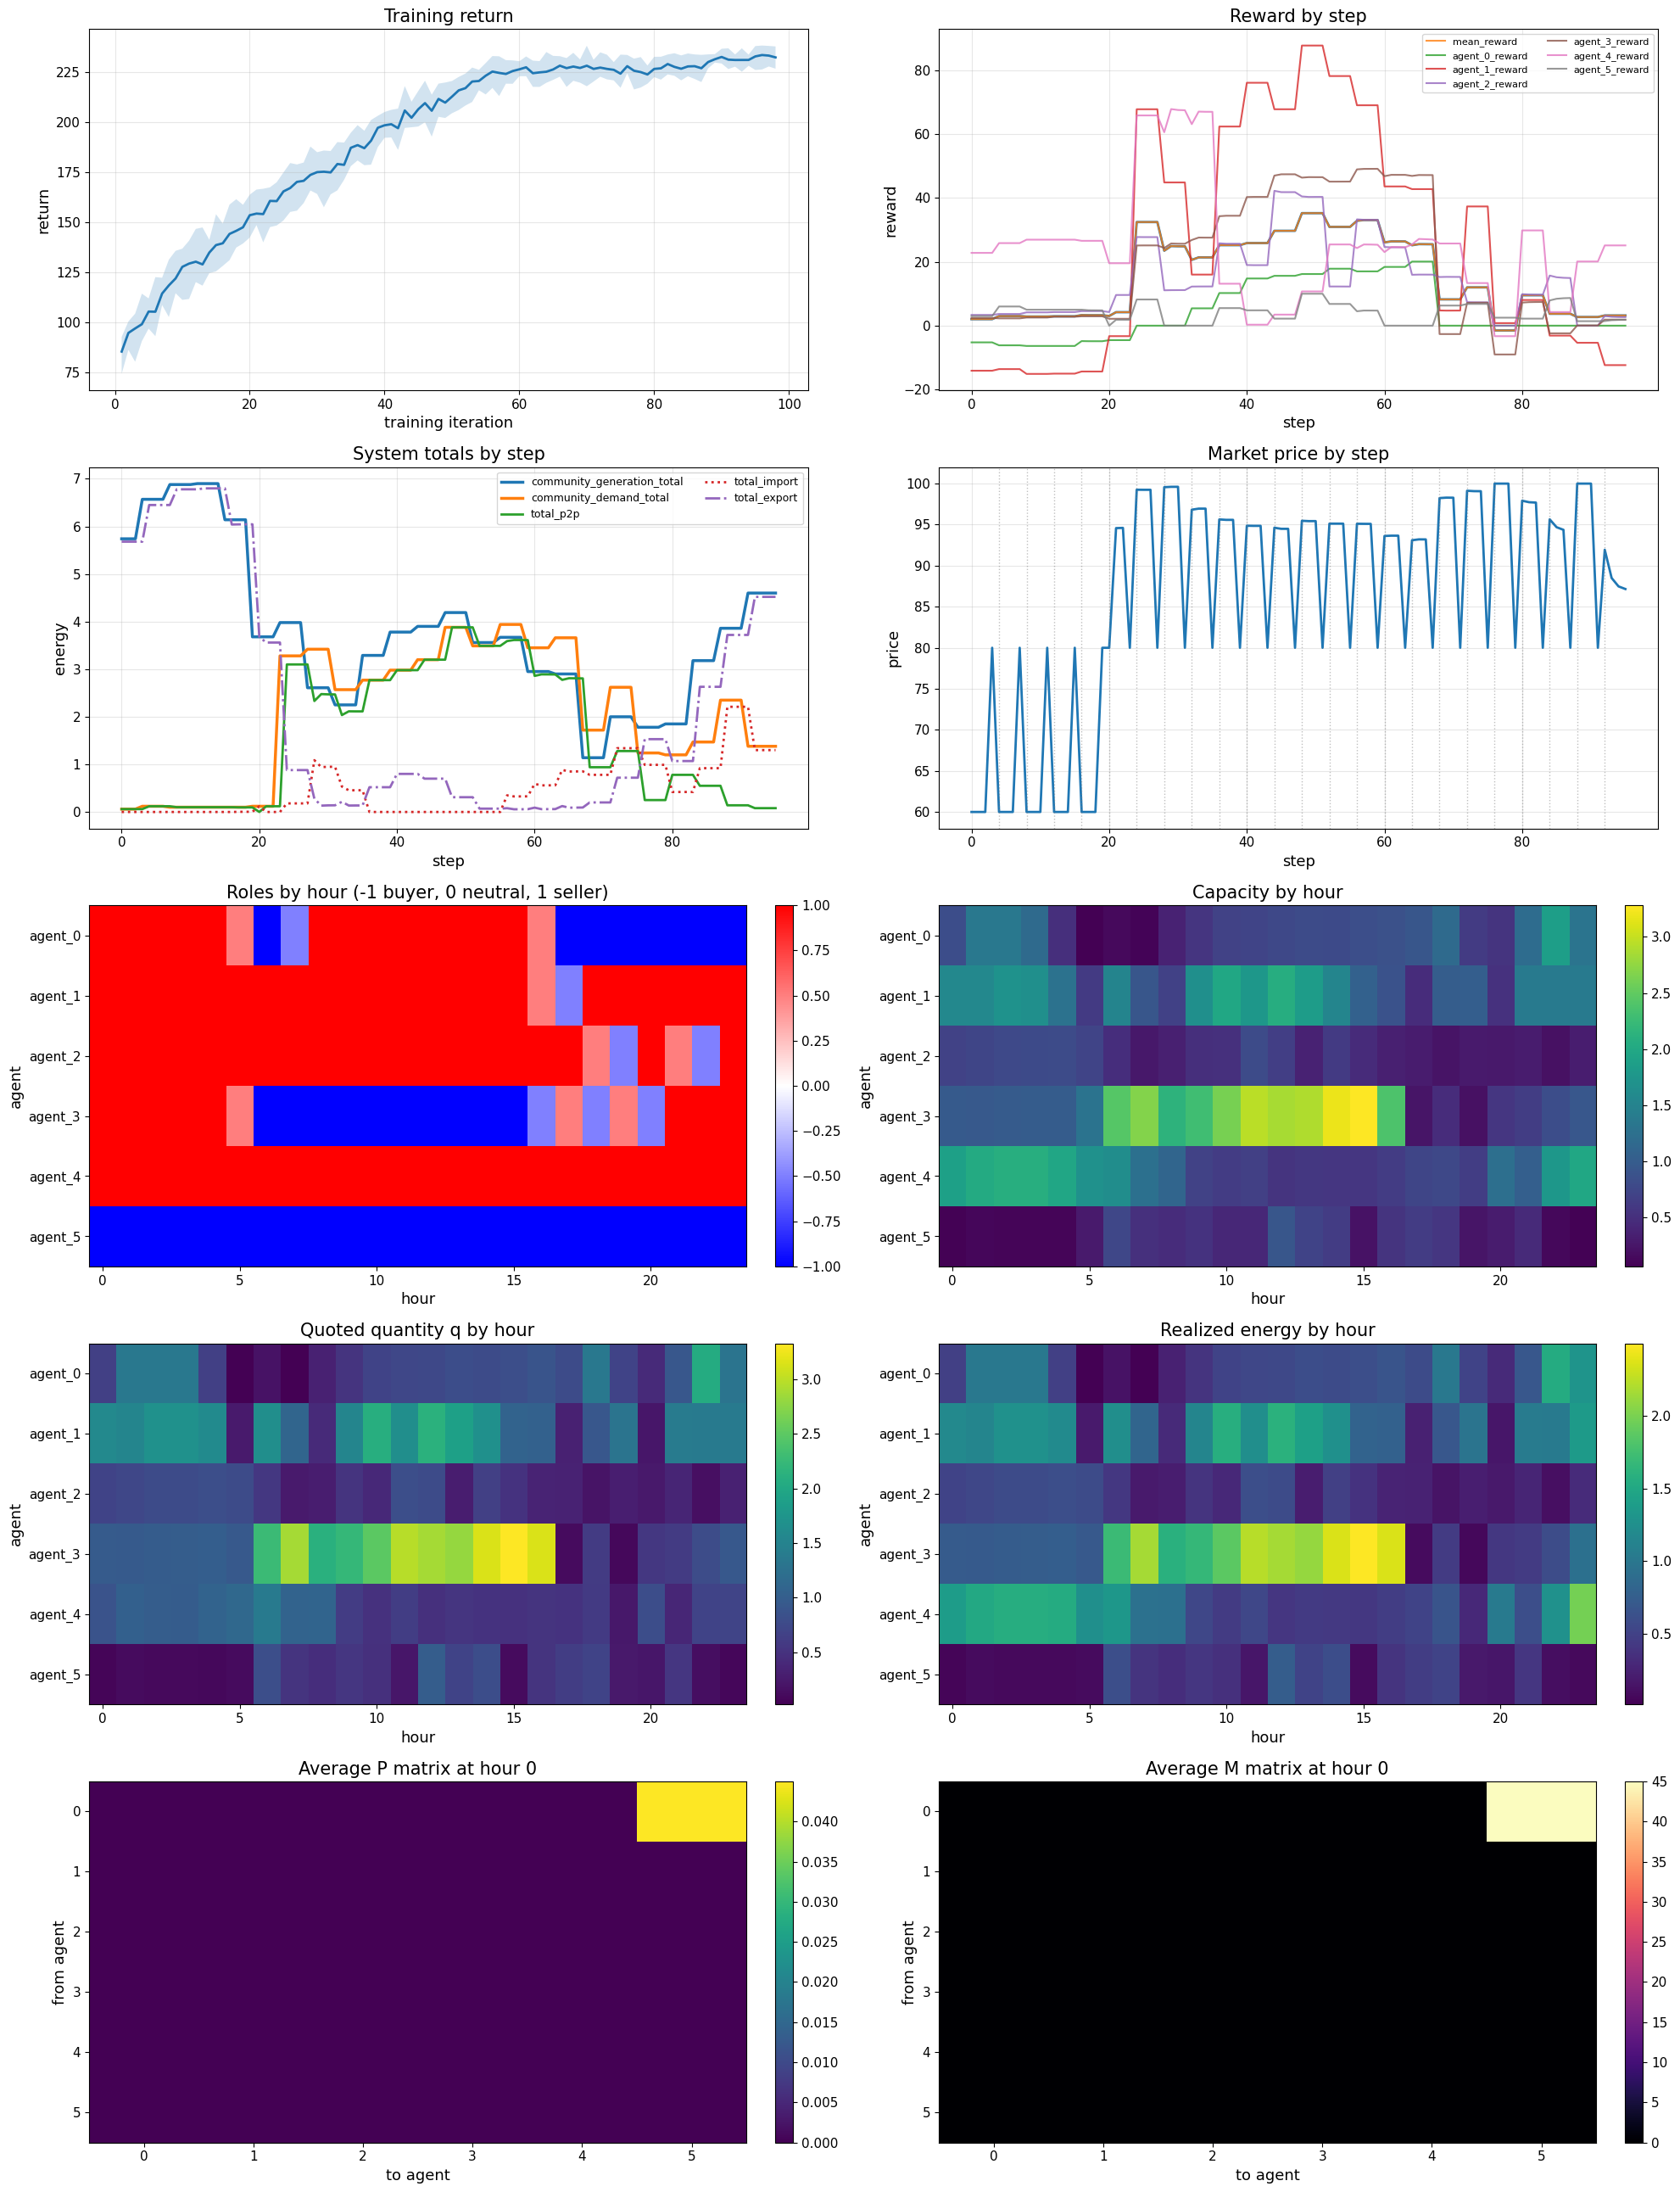

/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{prefix}_{r}_{c}"] = parsed.apply(
/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{prefix}_{r}_{c}"] = parsed.apply(
/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, u

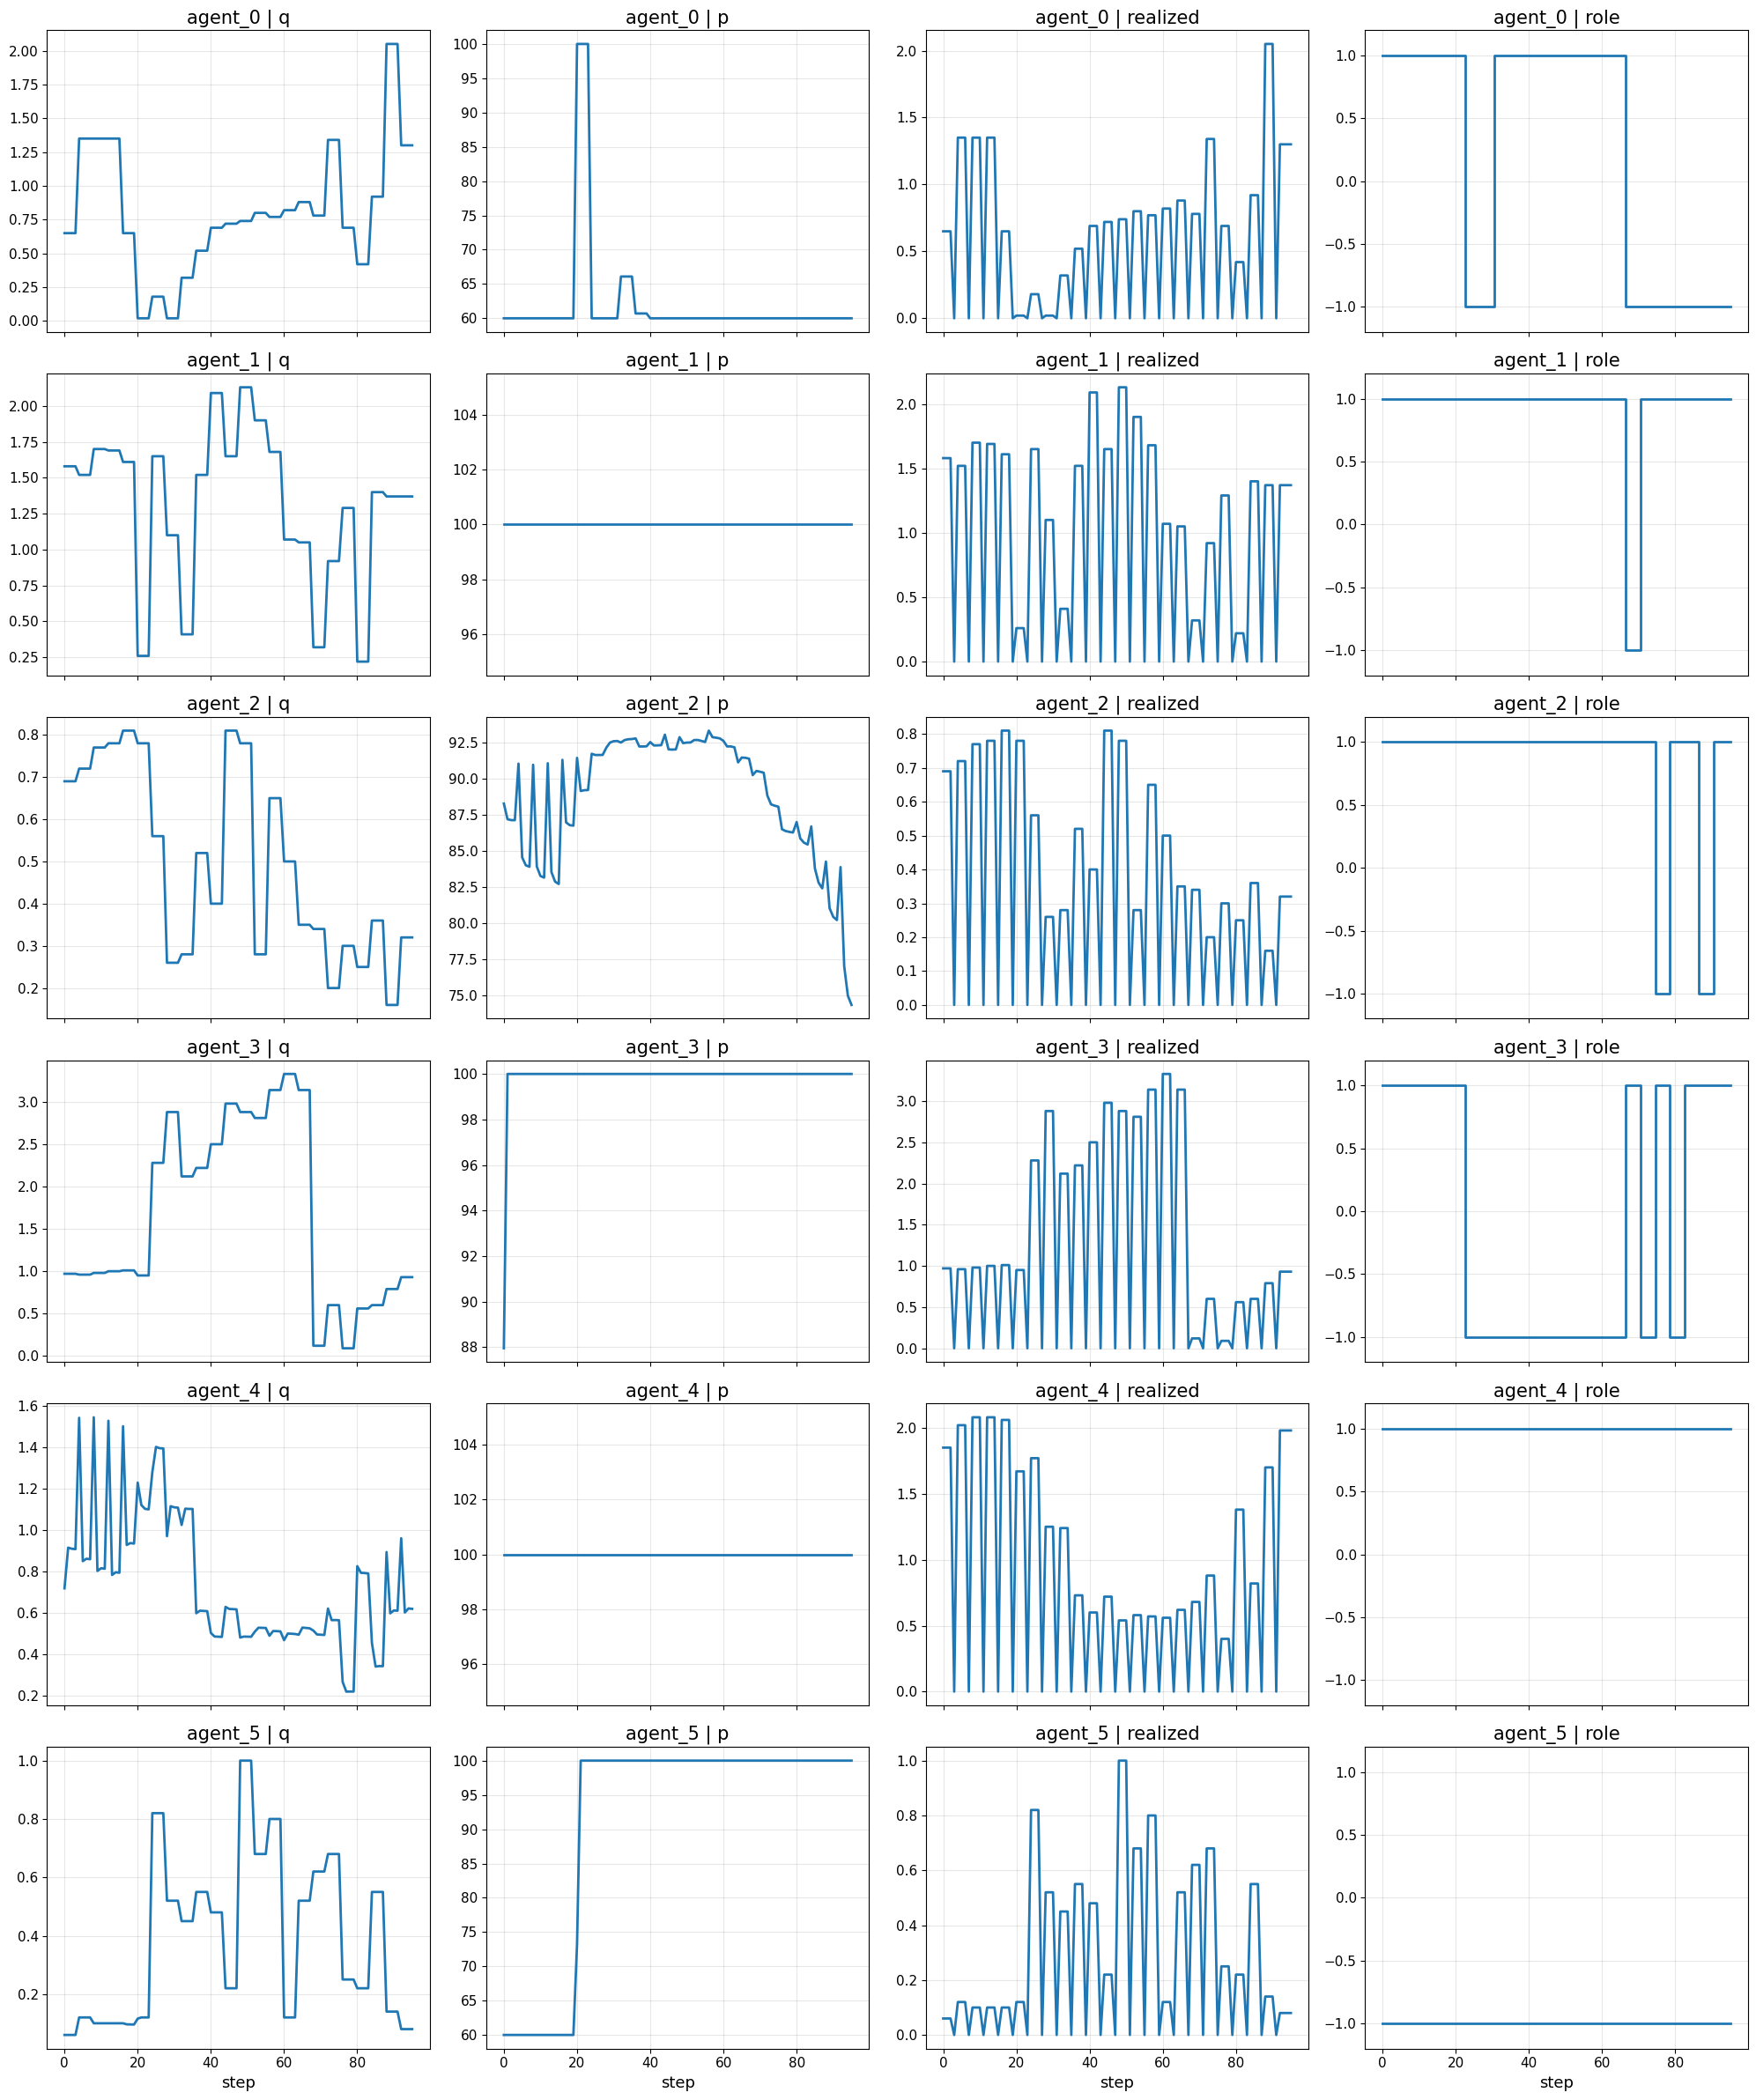

In [15]:

exp_name = "exp_results_2026-03-13_17-47-37"
algorithm = "PPO"

training_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/progress.csv"
eval_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/evaluation_agent_states.csv"
mu_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/custom_metrics.csv"

summary = full_analysis_plot_24h(
    training_path=training_path,
    eval_path=eval_path,
    mu_path=mu_path,
    selected_hour=0,
)

plot_agent_trajectories_24h(
    eval_path=eval_path,
    agents=summary["agent_ids"][:min(6, len(summary["agent_ids"]))],
)


/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{prefix}_{r}_{c}"] = parsed.apply(
/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{prefix}_{r}_{c}"] = parsed.apply(
/tmp/ipykernel_6686/1757527320.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, u

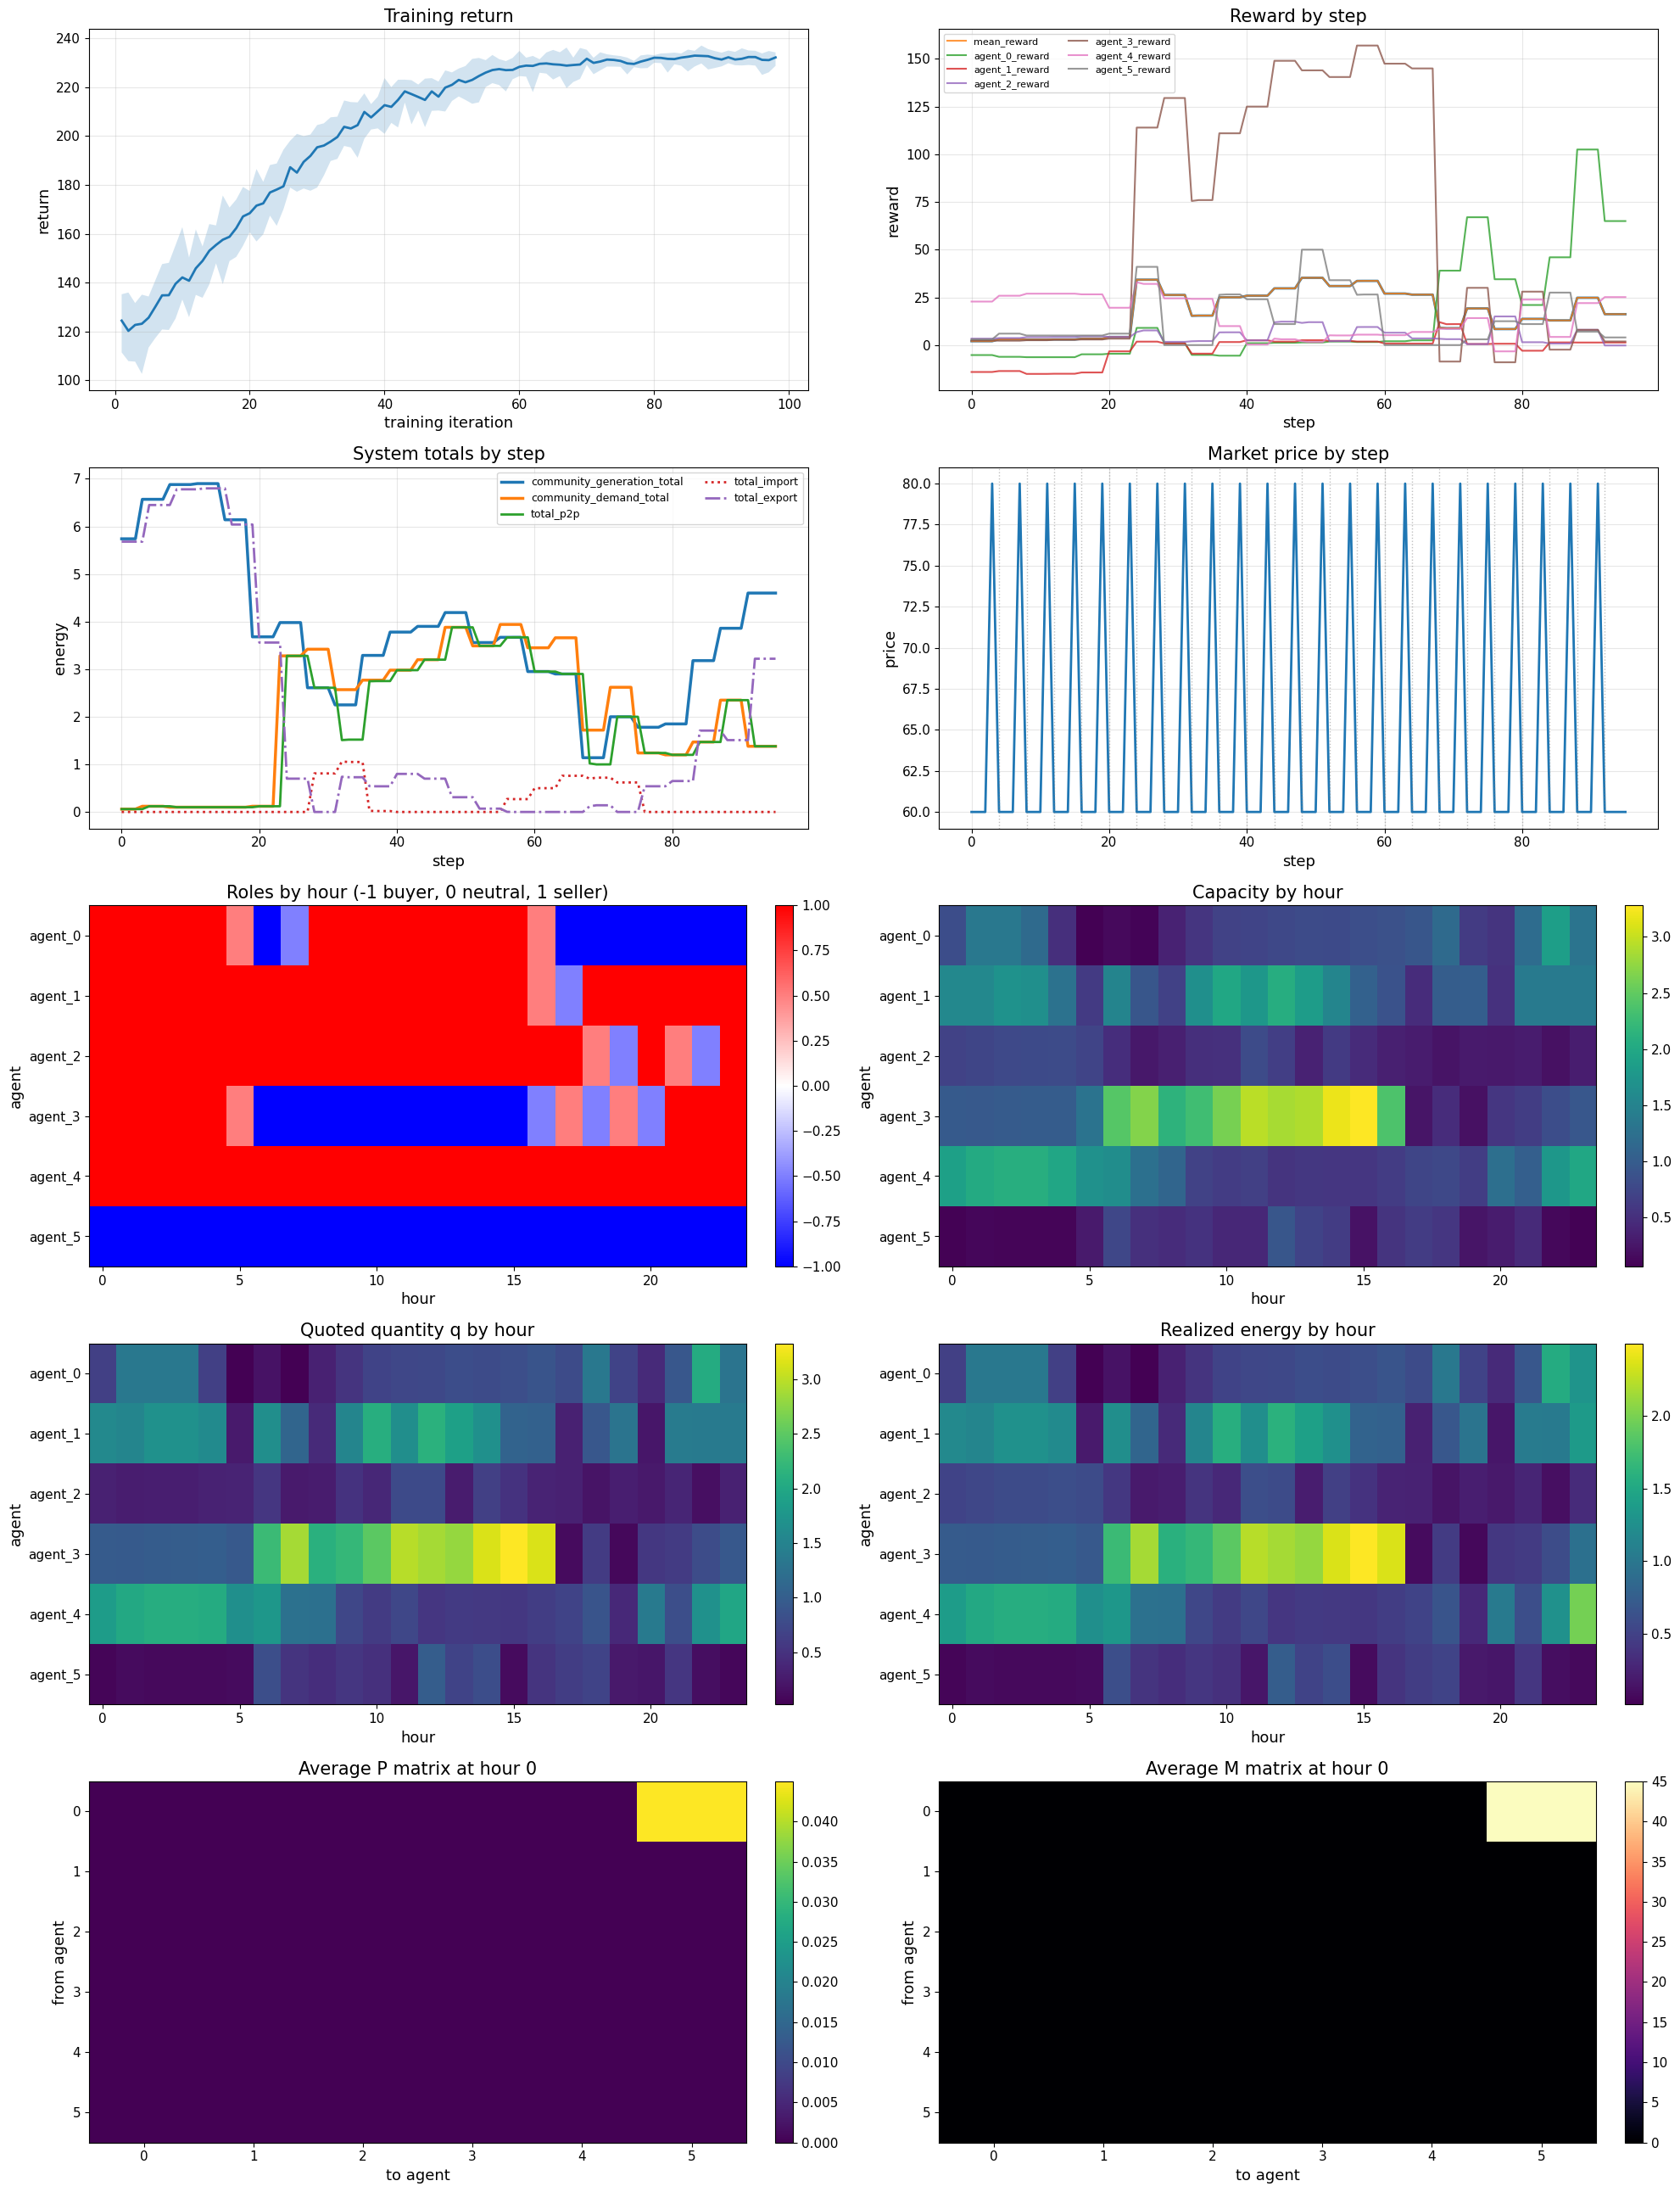

In [13]:

exp_name = "exp_results_2026-03-13_17-19-34"
algorithm = "PPO"

training_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/progress.csv"
eval_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/evaluation_agent_states.csv"
mu_path = f"./{exp_name}/energy_market_training/{algorithm}_energy_market_run/custom_metrics.csv"

summary = full_analysis_plot_24h(
    training_path=training_path,
    eval_path=eval_path,
    mu_path=mu_path,
    selected_hour=0,
)

# plot_agent_trajectories_24h(
#     eval_path=eval_path,
#     agents=summary["agent_ids"][:min(6, len(summary["agent_ids"]))],
# )
